## Random Tokens

In [1]:
import math
import time
import torch
import torch.nn as nn
import torch.nn.functional as F

In [3]:
# -----------------------------
# Device selection: CPU or MPS
# -----------------------------
def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

def mps_sync():
    # MPS ops are async; sync for accurate timing
    if torch.backends.mps.is_available():
        torch.mps.synchronize()

def mps_mem_mb():
    # Best-effort memory reporting for MPS
    if torch.backends.mps.is_available():
        allocated = torch.mps.current_allocated_memory()
        reserved = torch.mps.driver_allocated_memory()
        return allocated / (1024**2), reserved / (1024**2)
    return 0.0, 0.0

In [5]:
# ------------------------------------------
# Multi-Head Attention implemented "by hand"
# ------------------------------------------
class ScratchMHA(nn.Module):
    def __init__(self, d_model: int, n_heads: int, bias=True):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads

        self.Wq = nn.Linear(d_model, d_model, bias=bias)
        self.Wk = nn.Linear(d_model, d_model, bias=bias)
        self.Wv = nn.Linear(d_model, d_model, bias=bias)
        self.Wo = nn.Linear(d_model, d_model, bias=bias)

    def forward(self, x, attn_mask=None, need_weights=False):
        """
        x: (B, T, D)
        attn_mask: optional mask broadcastable to (B, H, T, T)
                   with True/1 for positions to mask (or -inf additive mask)
        """
        B, T, D = x.shape

        # 1) Project
        q = self.Wq(x)  # (B, T, D)
        k = self.Wk(x)
        v = self.Wv(x)

        # 2) Split into heads: (B, H, T, Dh)
        q = q.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        # 3) Attention scores: (B, H, T, T)
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_head)

        # 4) Apply mask (optional)
        if attn_mask is not None:
            # Two common mask styles:
            # - boolean mask where True means "mask out"
            # - additive mask with -inf where you want to mask
            if attn_mask.dtype == torch.bool:
                scores = scores.masked_fill(attn_mask, float("-inf"))
            else:
                scores = scores + attn_mask

        # 5) Softmax -> attention weights
        attn = F.softmax(scores, dim=-1)  # (B, H, T, T)

        # 6) Weighted sum of values
        out = attn @ v  # (B, H, T, Dh)

        # 7) Merge heads back: (B, T, D)
        out = out.transpose(1, 2).contiguous().view(B, T, D)

        # 8) Output projection
        out = self.Wo(out)

        if need_weights:
            return out, attn
        return out

In [7]:
# -----------------------------
# Timing + memory measurement
# -----------------------------
@torch.no_grad()
def benchmark(module, x, iters=50, warmup=10, label=""):
    module.eval()

    # Warmup
    for _ in range(warmup):
        _ = module(x)
    mps_sync()

    # Memory snapshot before
    mem0_alloc, mem0_res = mps_mem_mb()

    t0 = time.perf_counter()
    for _ in range(iters):
        _ = module(x)
    mps_sync()
    t1 = time.perf_counter()

    # Memory snapshot after
    mem1_alloc, mem1_res = mps_mem_mb()

    avg_ms = (t1 - t0) * 1000 / iters
    print(f"{label} avg latency: {avg_ms:.3f} ms/iter")

    if x.device.type == "mps":
        print(f"  MPS allocated memory: {mem0_alloc:.1f} -> {mem1_alloc:.1f} MB")
        print(f"  MPS driver memory:    {mem0_res:.1f} -> {mem1_res:.1f} MB")

def approx_mha_flops(B, T, D, H):
    """
    Very rough FLOPs estimate for forward pass (not counting projections precisely).
    Dominant terms:
      QK^T:   B*H*T*T*Dh * 2  (mul+add)
      AV:     B*H*T*T*Dh * 2
    where Dh = D/H
    => approx 4 * B * H * T^2 * Dh = 4 * B * T^2 * D
    """
    return 4 * B * (T**2) * D

def approx_attention_memory_bytes(B, H, T, dtype_bytes=2):
    """
    Attention matrix A is (B, H, T, T). If using fp16/bf16 ~2 bytes/element.
    """
    return B * H * T * T * dtype_bytes

In [9]:
# -----------------------------
# Main experiment
# -----------------------------
def run():
    # You can tweak these to see how time/memory scales
    B = 4      # batch size
    T = 512    # sequence length (this drives cost HARD because T^2)
    D = 512    # embedding dim
    H = 8      # heads
    dtype = torch.float16  # try float32 vs float16

    device = get_device()
    print("Using device:", device)

    mha = ScratchMHA(d_model=D, n_heads=H).to(device=device, dtype=dtype)

    x = torch.randn(B, T, D, device=device, dtype=dtype)

    # 1) Show shapes + pull attention weights once (small T recommended)
    # WARNING: attn weights are (B,H,T,T) and can be huge.
    if T <= 128:
        out, attn = mha(x, need_weights=True)
        print("x:", x.shape, "out:", out.shape, "attn:", attn.shape)
        # Example: attention distribution for token 0 attending to all tokens in head 0
        print("Example attn[batch0, head0, token0, :5] =", attn[0, 0, 0, :5])
    else:
        out = mha(x)
        print("x:", x.shape, "out:", out.shape, "(attention weights skipped for large T)")

    # 2) Benchmark
    benchmark(mha, x, iters=50, warmup=10, label="ScratchMHA")

    # 3) Rough FLOPs + memory estimate
    flops = approx_mha_flops(B, T, D, H)
    attn_mem = approx_attention_memory_bytes(B, H, T, dtype_bytes=2 if dtype in (torch.float16, torch.bfloat16) else 4)

    print(f"\nRough compute (dominant attention math only): ~{flops/1e9:.2f} GFLOPs per forward")
    print(f"Attention matrix size (B,H,T,T): {B}*{H}*{T}*{T} elements")
    print(f"Rough attention memory: ~{attn_mem/1024**2:.2f} MB just for A (not counting Q/K/V/out)")


In [11]:
run()

Using device: mps
x: torch.Size([4, 512, 512]) out: torch.Size([4, 512, 512]) (attention weights skipped for large T)
ScratchMHA avg latency: 4.639 ms/iter
  MPS allocated memory: 32.0 -> 32.0 MB
  MPS driver memory:    1072.5 -> 1072.5 MB

Rough compute (dominant attention math only): ~2.15 GFLOPs per forward
Attention matrix size (B,H,T,T): 4*8*512*512 elements
Rough attention memory: ~16.00 MB just for A (not counting Q/K/V/out)


## With Sentence

In [15]:
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel

In [17]:
# ============================================================
# 1. Device utils (Apple MPS-safe)
# ============================================================
def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

def sync():
    if torch.backends.mps.is_available():
        torch.mps.synchronize()

def mps_memory_mb():
    if torch.backends.mps.is_available():
        alloc = torch.mps.current_allocated_memory() / 1024**2
        driver = torch.mps.driver_allocated_memory() / 1024**2
        return alloc, driver
    return 0.0, 0.0


In [19]:
# ============================================================
# 2. Load model + tokenizer
# ============================================================
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

device = get_device()
model.to(device)
model.eval()

print("Using device:", device)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Using device: mps


In [21]:
# ============================================================
# 3. Input sentence
# ============================================================
sentence = "The cat sat on the mat because it was tired."
enc = tokenizer(sentence, return_tensors="pt")
input_ids = enc["input_ids"].to(device)
attention_mask = enc["attention_mask"].to(device)

tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
seq_len = len(tokens)

print("Tokens:", tokens)

Tokens: ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', 'because', 'it', 'was', 'tired', '.', '[SEP]']


In [29]:
# ============================================================
# 4. Forward pass with timing + GPU memory
# ============================================================
# Warm-up (important for MPS)
for _ in range(5):
    _ = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        output_attentions=True
    )
sync()
# Memory before
mem_before = mps_memory_mb()

# Timed forward pass
start = time.perf_counter()
with torch.no_grad():
    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        output_attentions=True,
        return_dict=True
    )
sync()
end = time.perf_counter()

mem_after = mps_memory_mb()

elapsed_ms = (end - start) * 1000

print("\n--- Performance ---")
print(f"Forward pass time: {elapsed_ms:.3f} ms")
print(f"MPS allocated memory: {mem_before[0]:.2f} → {mem_after[0]:.2f} MB")
print(f"MPS driver memory:    {mem_before[1]:.2f} → {mem_after[1]:.2f} MB")


--- Performance ---
Forward pass time: 7.179 ms
MPS allocated memory: 300.91 → 301.26 MB
MPS driver memory:    1074.73 → 1074.73 MB


In [31]:
# ============================================================
# 5. Extract attention maps
# ============================================================
attentions = outputs.attentions
num_layers = len(attentions)
num_heads = attentions[0].shape[1]

layer_idx = 2
head_idx = 3

# (seq_len, seq_len)
attn_head = attentions[layer_idx][0, head_idx].detach().cpu().numpy()
attn_avg = attentions[layer_idx][0].mean(dim=0).detach().cpu().numpy()

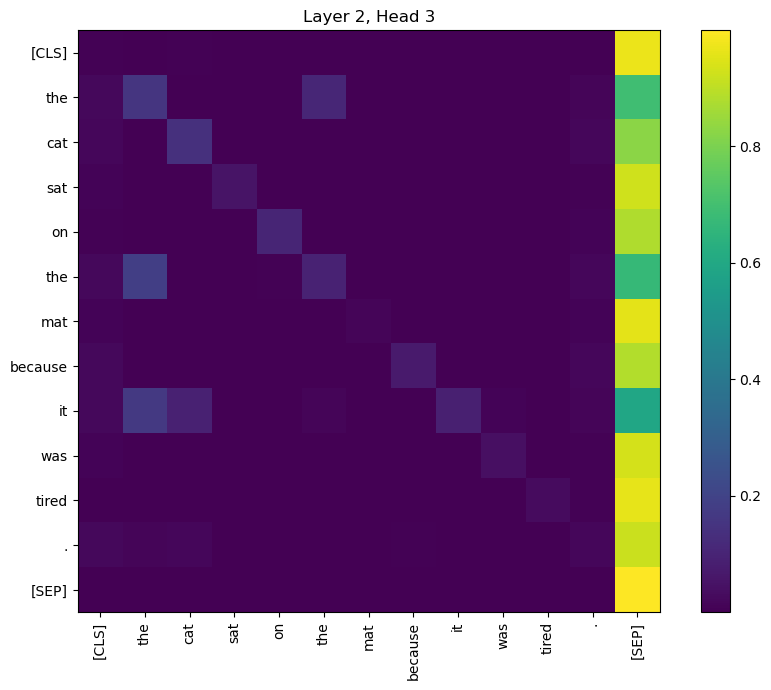

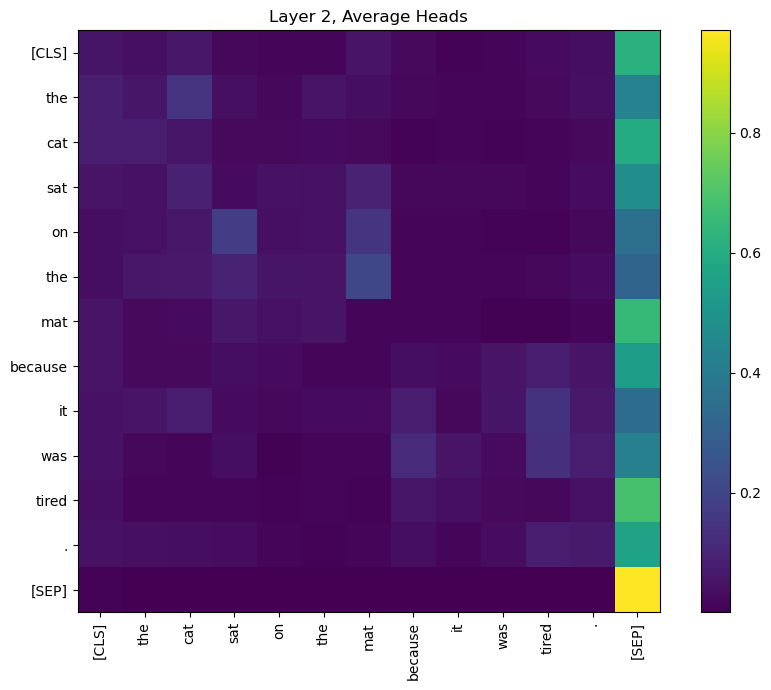

In [33]:
# ============================================================
# 6. Plot attention heatmaps
# ============================================================
def plot_attention(A, tokens, title):
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(A, cmap="viridis")
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=90)
    ax.set_yticklabels(tokens)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

plot_attention(attn_head, tokens, f"Layer {layer_idx}, Head {head_idx}")
plot_attention(attn_avg, tokens, f"Layer {layer_idx}, Average Heads")

In [35]:
# ============================================================
# 7. Inspect attention from a specific word
# ============================================================
word = "it"
if word in tokens:
    idx = tokens.index(word)
    weights = attn_avg[idx]
    top = np.argsort(-weights)[:6]

    print(f"\nTop attention targets FROM '{word}':")
    for j in top:
        print(f"  → {tokens[j]:>10s}: {weights[j]:.4f}")


Top attention targets FROM 'it':
  →      [SEP]: 0.3427
  →      tired: 0.1416
  →    because: 0.0803
  →        cat: 0.0786
  →          .: 0.0679
  →        was: 0.0556


Using device: mps


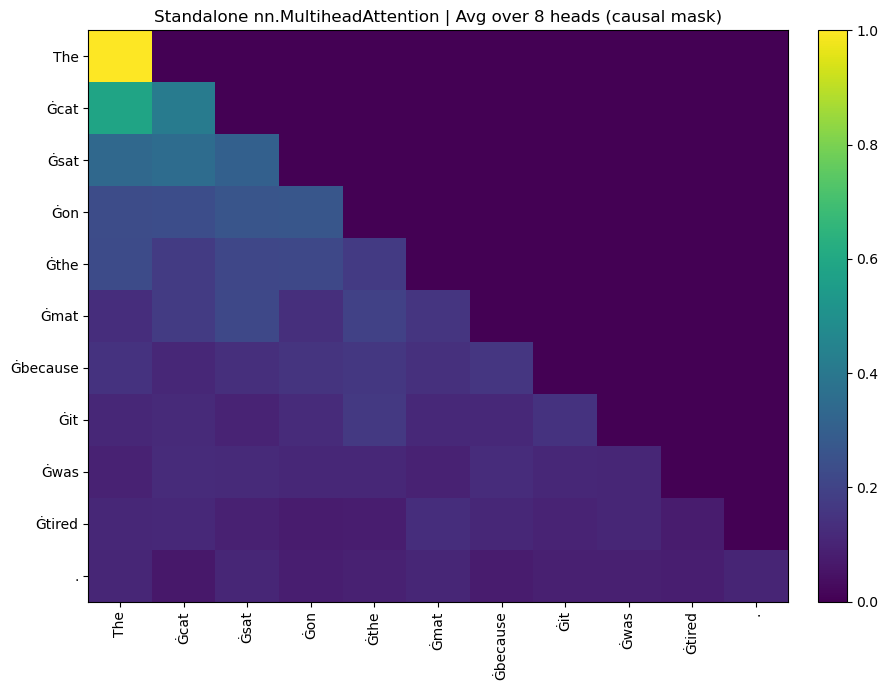

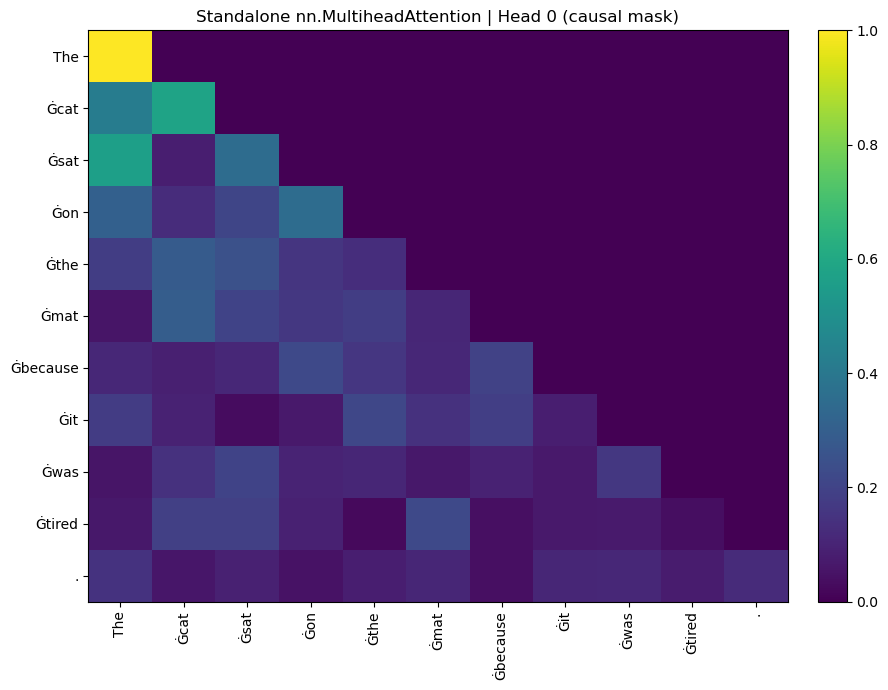

In [40]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

# Example tokens (same sentence tokens from GPT-2 tokenizer style)
tokens = ["The", "Ġcat", "Ġsat", "Ġon", "Ġthe", "Ġmat", "Ġbecause", "Ġit", "Ġwas", "Ġtired", "."]
T = len(tokens)

# Toy embeddings (random) -> (T, B, D) for nn.MultiheadAttention (default batch_first=False)
B = 1
D = 128
H = 8
dtype = torch.float16 if device.type == "mps" else torch.float32

x = torch.randn(T, B, D, device=device, dtype=dtype)

mha = nn.MultiheadAttention(embed_dim=D, num_heads=H, batch_first=False).to(device, dtype=dtype)
mha.eval()

# causal mask: block future attention (upper triangle)
causal_mask = torch.triu(torch.ones(T, T, device=device, dtype=torch.bool), diagonal=1)

with torch.no_grad():
    # need_weights=True returns averaged weights by default unless average_attn_weights=False
    out, attn_avg = mha(
        x, x, x,
        attn_mask=causal_mask,
        need_weights=True,
        average_attn_weights=True  # (B, T, T)
    )

A = attn_avg[0].detach().float().cpu().numpy()  # (T,T)

def plot_map(A, tokens, title):
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(A, aspect="auto")
    ax.set_title(title)
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=90)
    ax.set_yticklabels(tokens)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

plot_map(A, tokens, f"Standalone nn.MultiheadAttention | Avg over {H} heads (causal mask)")

# If you want per-head weights:
with torch.no_grad():
    out2, attn_per_head = mha(
        x, x, x,
        attn_mask=causal_mask,
        need_weights=True,
        average_attn_weights=False  # (B, H, T, T)
    )

A_h = attn_per_head[0, 0].detach().float().cpu().numpy()  # head 0
plot_map(A_h, tokens, "Standalone nn.MultiheadAttention | Head 0 (causal mask)")
